In [1]:
from glob import glob
import csv
import json
import pandas as pd
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

import statistics
import scipy.stats as stats

from adjustText import adjust_text

import networkx as nx

from sklearn.manifold import MDS
from sklearn.decomposition import PCA

import umap
import re

import numpy as np



In [2]:
SCENARIO = "ScarboroughShoalUN"
MODEL = "qwen"

In [3]:
# rename the game data to CSV.. 
import os
for file in glob(f"results/{SCENARIO}/{MODEL}/**/game_*.json"):
    newname = file.replace(".json", ".csv")
    if not os.path.exists(newname):
        os.rename(file, newname)

In [4]:
# ## question 0, read in the leader names
leader_names = {}
with open("results/leader_names.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        leader_names[int(row['idx'])] = row

leader_names

{0: {'idx': '0', 'name': 'Lee Jae Myung'},
 1: {'idx': '1', 'name': 'Ferdinand "Bongbong" Marcos Jr'},
 2: {'idx': '2', 'name': 'Takeshi Iwaya'},
 3: {'idx': '3', 'name': 'Joko Widodo'},
 4: {'idx': '4', 'name': 'Lai Ching-te'},
 5: {'idx': '5', 'name': 'Tsai Ing-wen'},
 6: {'idx': '6', 'name': 'Xi Jinping'},
 7: {'idx': '7', 'name': 'Hun Manet'},
 8: {'idx': '8', 'name': 'Kim Jong-Un'},
 9: {'idx': '9', 'name': 'Sara Duterte'},
 10: {'idx': '10', 'name': 'Lương Cường'},
 11: {'idx': '11', 'name': 'Anutin Charnvirakul'},
 12: {'idx': '12', 'name': 'Sanae Takaichi'},
 13: {'idx': '13', 'name': 'Cho Hyun'},
 14: {'idx': '14', 'name': 'Hassanal Bolkiah'},
 15: {'idx': '15', 'name': 'Kim Min-seok'},
 16: {'idx': '16', 'name': 'Min Aung Hlaing'},
 17: {'idx': '17', 'name': 'Thongloun Sisoulith'},
 18: {'idx': '18', 'name': 'Anwar Ibrahim'}}

/tmp/ipykernel_3716408/4221851923.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Condition', y='Score', data=df_long,


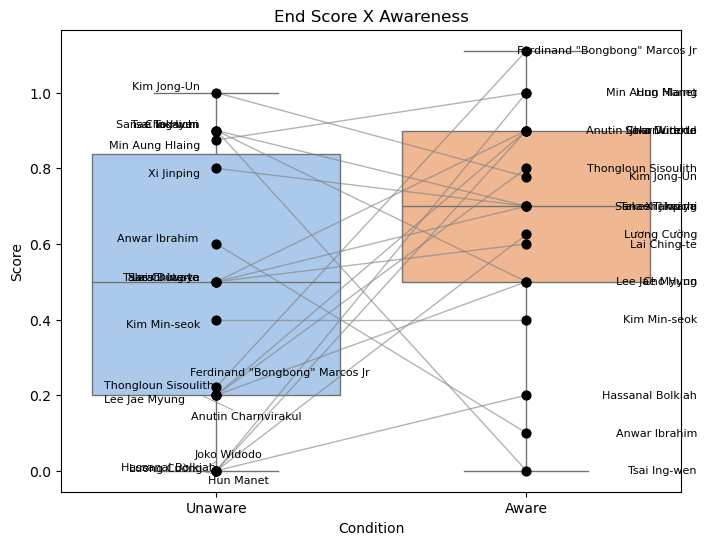

In [5]:
## question 1, how does awareness of the partner change the final score?

# get the final scores of the rounds where they know about their partner
aware_scores = defaultdict(list)
unaware_scores = defaultdict(list)

for file in glob(f"results/{SCENARIO}/{MODEL}/**/game_*.csv"):
    is_aware = "/aware/" in file
    with open(file, "r") as f:
        data = pd.read_csv(f)
        maxrnd = max(data['Round'])
        final_scores = data[data['Round'] == maxrnd]
        for _, row in final_scores.iterrows():
            if is_aware:
                aware_scores[row['Player']].append(row['Total Points'])
            else:
                unaware_scores[row['Player']].append(row['Total Points'])

# transform the data 
# data = {
#     'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank'],
#     'Before': [35, 42, 28, 50, 45, 30],
#     'After': [48, 45, 35, 48, 55, 40]
# }
data = {'Name': [], 'Unaware': [], 'Aware': []}

for idx in leader_names:
    name = leader_names[idx]['name']

    u = unaware_scores.get(idx, [])
    a = aware_scores.get(idx, [])

    # Only keep leaders that appear in BOTH conditions
    if len(u) == 0 or len(a) == 0:
        print(f"Skipping leader {idx}: unaware={len(u)}, aware={len(a)}")
        continue

    before = statistics.mean(u)
    after = statistics.mean(a)

    data['Name'].append(name)
    data['Unaware'].append(before)
    data['Aware'].append(after)


# now, make the comparison chart
df = pd.DataFrame(data)

# Convert to long format for Seaborn (Boxplot requires tidy data)
df_long = pd.melt(df, id_vars=['Name'], var_name='Condition', value_name='Score')

# 2. Setup the plot
plt.figure(figsize=(8, 6))

# 3. Create the Box Plot
# We turn off outliers (showfliers=False) because we will plot the actual points
ax = sns.boxplot(x='Condition', y='Score', data=df_long, 
                 palette="pastel", showfliers=False)

# 4. Iterate through the original dataframe to draw lines and labels
# In a standard boxplot: x-axis 0 is the first category ('Before'), x-axis 1 is the second ('After')
texts = []
for i in range(len(df)):
    # Get the data for this specific individual
    y1 = df['Unaware'][i]
    y2 = df['Aware'][i]
    name = df['Name'][i]
    
    # Plot the line connecting the two points (x=0 and x=1)
    plt.plot([0, 1], [y1, y2], color='gray', linestyle='-', alpha=0.6, linewidth=1)
    
    # Plot the specific dots on top of the boxplot to make them visible
    plt.scatter([0, 1], [y1, y2], color='black', s=40, zorder=3)
    
    # 5. Add Labels
    # Here we label the 'Before' side (x=0). 
    # We offset x slightly (-0.05) to push the text to the left.
    t1 = plt.text(x=-0.05, y=y1, s=name, 
             horizontalalignment='right', 
             verticalalignment='center', 
            fontsize=8,
             color='black')
    t2 = plt.text(x=1.55, y=y2, s=name, 
             horizontalalignment='right', 
             verticalalignment='center', 
            fontsize=8,
             color='black')
    texts.append(t1)
    # texts.append(t2)

adjust_text(texts, 
            only_move={'points':'y', 'text':'y'}, # Constrain movement to Y-axis (mostly)
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Aesthetics
plt.title("End Score X Awareness")
plt.ylabel("Score")
plt.xlabel("Condition")

# Optional: Add margins so labels don't get cut off
plt.xlim(-0.5, 1.5)

plt.show()

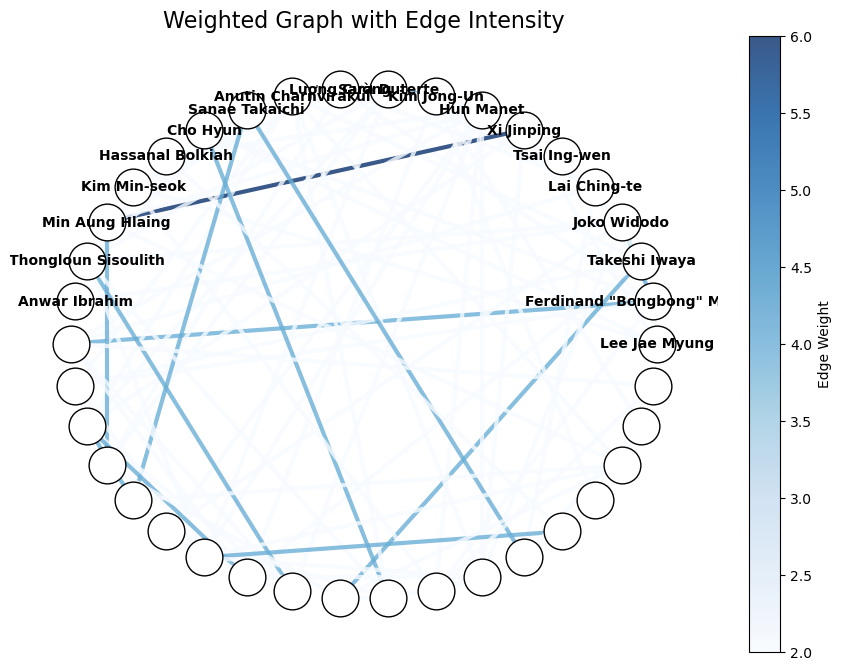

In [6]:
## question 2, who is most likely to agree with whom (when they know who is who)

G = nx.Graph()
G.add_nodes_from(leader_names.keys())

labels = {idx: leader_names[idx]['name'] for idx in leader_names}

for file in glob(f"results/{SCENARIO}/{MODEL}/aware/game_*.csv"):
    with open(file, "r") as f:
        data = pd.read_csv(f)
        # get all after the first round
        data = data[data['Round'] > 5]
        for _, row in data.iterrows():
            if row['Hashtag'] == row['Partner Hashtag']:
                # they agreed
                if G.has_edge(row['Player'], row['Partner']):
                    G[row['Player']][row['Partner']]['weight'] += 1
                else:
                    G.add_edge(row['Player'], row['Partner'], weight=1)

# 2. Extract weights for coloring
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]

# 3. Choose a layout (Spring layout usually looks best for general graphs)
# seed ensures reproducibility
# pos = nx.spring_layout(G, seed=42, k=2)  # k regulates distance between nodes
pos = nx.circular_layout(G)  # alternative layout

plt.figure(figsize=(10, 8))

# 4. Draw Nodes
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='white', edgecolors='black')

# Draw Labels (The Key Step)
# We pass our dictionary 'labels' here
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_family='sans-serif', font_weight='bold')

# 5. Draw Labels
# nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif')

# 6. Draw Edges with Colors
# - edge_color: passes the list of weights
# - edge_cmap: the colormap (Blues)
# - width: making edges slightly thicker helps see the color
edges_drawing = nx.draw_networkx_edges(
    G, pos,
    edgelist=edges,
    edge_color=weights,
    edge_cmap=plt.cm.Blues,
    width=3,
    alpha=0.8
)

# 7. Add a Colorbar
# We need to tell the colorbar what the "mappable" object is (the edges)
plt.colorbar(edges_drawing, label='Edge Weight', fraction=0.046, pad=0.04)

plt.title("Weighted Graph with Edge Intensity", fontsize=16)
plt.axis('off') # Hide the axis frame
plt.show()


Stress: 5.731633643545831


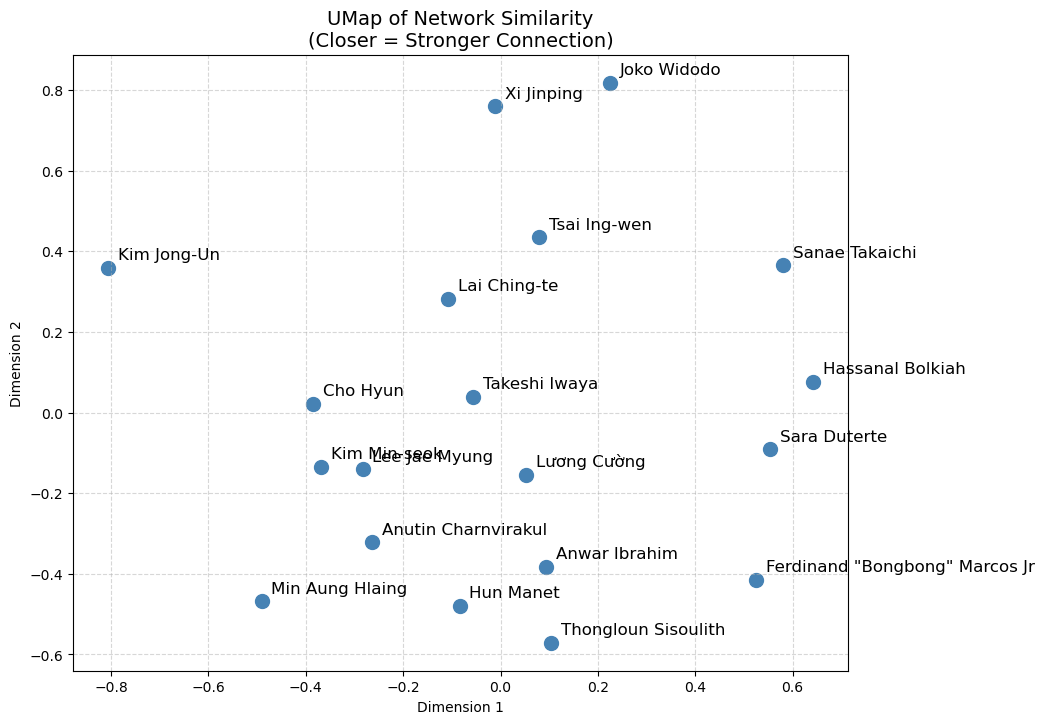

In [7]:
## question 2a, the same thing but as an MDS plot
# 2. Compute the Distance Matrix (All-Pairs Shortest Path)
# We use 'dist' (1/weight) so strong connections pull nodes closer
# 0. Invert weights to distances
for u, v, d in G.edges(data=True):
    d["dist"] = 1.0 / d["weight"]

# 1. Take largest connected component
Gcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
my_nodelist = list(Gcc.nodes())

# 2. Compute distance matrix
distance_matrix = nx.floyd_warshall_numpy(Gcc, nodelist=my_nodelist, weight="dist")

# 3. MDS
mds = MDS(
    n_components=2,
    dissimilarity='precomputed',
    metric=True,
    random_state=42,
    normalized_stress="auto"
)

pos_array = mds.fit_transform(distance_matrix)
print("Stress:", mds.stress_)


# embedding = umap.UMAP(
#     n_neighbors=5,
#     min_dist=0.1,
#     n_components=2,  # Dimensions to reduce to
#     metric='euclidean', # Try 'cosine' if euclidean gives poor results
#     random_state=42
# )
# pos_array = embedding.fit_transform(distance_matrix)

# pca = PCA(n_components=2)
# pos_array = pca.fit_transform(distance_matrix)
# print("Explained:", pca.explained_variance_ratio_)



# 4. Plotting
plt.figure(figsize=(10, 8))

# Draw the points
plt.scatter(pos_array[:, 0], pos_array[:, 1], color='steelblue', s=100)

# Add labels
# We nudge the labels slightly so they don't cover the dots
for idx, node in enumerate(my_nodelist):
    name = leader_names[node]['name']
    plt.text(pos_array[idx, 0] + 0.02, pos_array[idx, 1] + 0.02, name, fontsize=12)

plt.title("UMap of Network Similarity\n(Closer = Stronger Connection)", fontsize=14)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [8]:
## question 3, what is the difference between tweets pre-post interaction?
# funnel plot

In [8]:
## question 4, how does the number of quotes affect the score?
fnre = re.compile(r"game_data_(?P<run>\d+)_(?P<quotes>\d+)_quotes_run\d+.csv")

leaders2quotes2scores = defaultdict(lambda: defaultdict(list))

for file in glob(f"results/{SCENARIO}/{MODEL}/**/game_*.csv"):
    is_aware = "/aware/" in file
    if is_aware:
        continue

    # pull the number of quotes from the file name... 
    match = fnre.match(os.path.basename(file))
    g = match.groupdict()
    quotes = int(g['quotes'])

    with open(file, "r") as f:
        data = pd.read_csv(f)
        maxrnd = max(data['Round'])
        final_scores = data[data['Round'] == maxrnd]
        for _, row in final_scores.iterrows():
            leaders2quotes2scores[row['Player']][quotes].append(row['Total Points'])

# Setup the plot grid
leaders = sorted(list(leaders2quotes2scores.keys()))
num_leaders = len(leaders)
cols = 3
rows = (num_leaders + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), sharex=True, sharey=True)
if num_leaders > 1:
    axes = axes.flatten()
else:
    axes = [axes] # Handle single plot case

for idx, leader in enumerate(leaders):
    ax = axes[idx]
    quotes_data = leaders2quotes2scores[leader]
    
    xs = []
    means = []
    cis_lower = []
    cis_upper = []
    
    # Sort by x-axis values
    sorted_quotes = sorted(quotes_data.keys())
    
    for q in sorted_quotes:
        scores = quotes_data[q]
        if not scores:
            continue
            
        mu = np.mean(scores)
        sigma = np.std(scores)
        n = len(scores)
        
        # Calculate 95% Confidence Interval
        se = sigma / np.sqrt(n) if n > 0 else 0
        ci = 1.96 * se
            
        xs.append(q)
        means.append(mu)
        cis_lower.append(mu - ci)
        cis_upper.append(mu + ci)
        
    ax.plot(xs, means, marker='o', markersize=4)
    ax.fill_between(xs, cis_lower, cis_upper, alpha=0.3)
    
    ax.set_title(leader_names[leader]['name'])
    ax.set_xlabel("Number of Quotes")
    ax.set_ylabel("Mean Score")
    ax.grid(True, linestyle='--', alpha=0.5)

# Hide empty subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

AttributeError: 'NoneType' object has no attribute 'groupdict'

In [9]:
!pip install nltk
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /nas/home/abhajha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

7 [-0.94260203  0.66146971]
9 [ 0.27345457 -0.54324716]
1 [0.54419621 0.00811084]
11 [0.01055482 0.55966171]
8 [0.00438307 0.44045681]
9 [-0.73432086  0.06530295]
3 [-0.59926294 -0.00688765]
6 [-0.32322456  0.02397272]


Text(42.597222222222214, 0.5, 'log(Post / Pre Mention Ratio)')

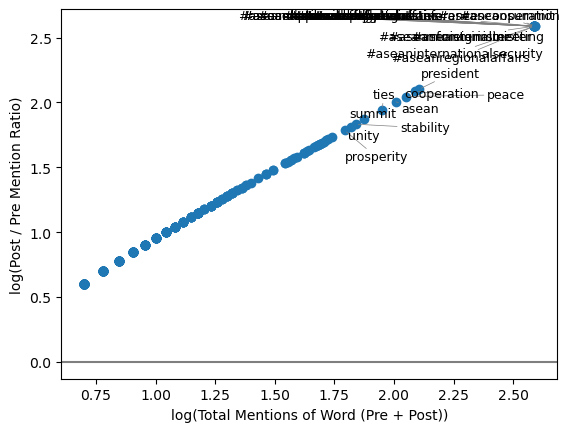

In [10]:
from collections import Counter
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
import string

STOPWORDS = set(stopwords.words("english"))

# add Twitter / punctuation noise
STOPWORDS |= {
    "rt", "&amp;", "https", "http", "co", "#", "@", "’", "“", "”"
}

# optionally remove pure punctuation tokens
PUNCT = set(string.punctuation)

def clean_tokens(tokens):
    return [
        w.lower()
        for w in tokens
        if w.lower() not in STOPWORDS
        and w not in PUNCT
        and any(c.isalpha() for c in w)  # keeps words like "asean", drops "..."
    ]


tknzr = TweetTokenizer()

# Let's see how Marcos' language changes pre/post
LEADER = "Ferdinand \"Bongbong\" Marcos Jr, the President of Philippines"

prewords = Counter()
postwords = Counter()

for file in glob("results/aware/pre*.json"):
    with open(file, "r") as f:
        data = json.load(f)
        for _, tweet in data.items():
            words = tknzr.tokenize(tweet)
            prewords.update(clean_tokens(words))


for file in glob(f"results/{SCENARIO}/{MODEL}/aware/post*.json"):
    with open(file, "r") as f:
        data = json.load(f)
        for _, tweet in data.items():
            words = tknzr.tokenize(tweet)
            postwords.update(clean_tokens(words))


# 1. Define your Baseline (p)
# If Pre and Post datasets have equal total word counts, p = 0.5.
# If Post is longer, p = Total_Post_Words / Total_Experiment_Words
p_baseline = 0

# 2. Create the Funnel Lines
# X-axis values (Total mentions of a word: 1 to 1000)
n_values = np.logspace(0, 4, 100) 

# Calculate the upper and lower bounds (99.9% confidence)
# This asks: "If a word appears n times, what is the max count we expect by chance?"
upper_bound = stats.binom.ppf(0.999, n_values, p_baseline) / n_values
lower_bound = stats.binom.ppf(0.001, n_values, p_baseline) / n_values

# 3. Plot
plt.axhline(p_baseline, color='black', alpha=0.5)

# Now scatter plot your actual words on top of this!
x = []
y = []
xywords = []
for word in set(prewords.keys()).union(set(postwords.keys())):
    word_count_pre = prewords.get(word, 0) + 1
    word_count_post = postwords.get(word, 0) + 1
    total_count = word_count_pre + word_count_post
    if total_count < 5:
        continue  # Skip rare words for clarity
    
    x.append(np.log(total_count) / np.log(10))
    y.append(np.log(word_count_post / word_count_pre) / np.log(10))
    xywords.append((np.log(total_count) / np.log(10), 
                    np.log(word_count_post / word_count_pre) / np.log(10), 
                    word))

plt.scatter(x,y)

# annotate the top 20 words
xywords = sorted(xywords, key=lambda item: item[0] * abs(item[1]), reverse=True)[:30]
texts = []
for x_val, y_val, word in xywords:
    texts.append(
        plt.text(
            x=x_val, 
            y=y_val,
            s=word,
            fontsize=9
        )
    )
adjust_text(
    texts, 
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

plt.xlabel("log(Total Mentions of Word (Pre + Post))")
plt.ylabel("log(Post / Pre Mention Ratio)")